# Techniques de Régularisation en Deep Learning avec CIFAR-10

Ce notebook explore les principales techniques pour éviter le **surapprentissage (overfitting)** :
1. **Baseline** (Sans régularisation)
2. **Régularisation L2** (Weight Decay)
3. **Dropout**
4. **Batch Normalization**
5. **Data Augmentation**
6. **Early Stopping**

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, regularizers
import matplotlib.pyplot as plt
import numpy as np

# Chargement des données CIFAR-10
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalisation des pixels entre 0 et 1
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['avion', 'automobile', 'oiseau', 'chat', 'cerf', 'chien', 'grenouille', 'cheval', 'bateau', 'camion']

print(f"Données chargées : {train_images.shape[0]} images d'entraînement, {test_images.shape[0]} images de test.")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Données chargées : 50000 images d'entraînement, 10000 images de test.


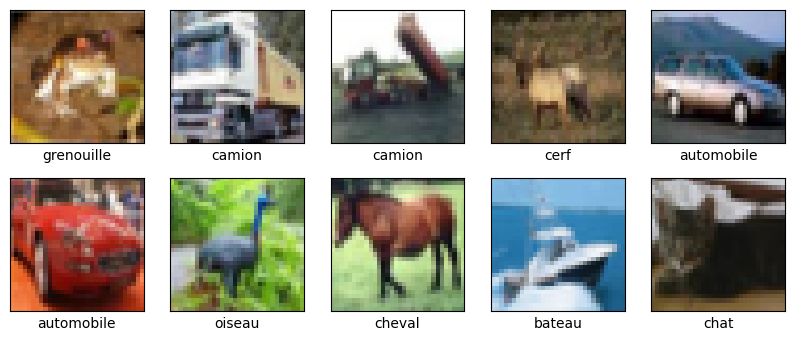

In [2]:
# Visualisation de quelques images
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

## Fonction utilitaire pour l'affichage des courbes
Pour comparer nos modèles, nous allons tracer l'évolution de la précision (accuracy) et de la perte (loss).

In [3]:
def plot_history(histories, key='accuracy'):
    plt.figure(figsize=(12, 6))
    for name, history in histories:
        val = plt.plot(history.epoch, history.history['val_'+key], '--', label=name+' Test')
        plt.plot(history.epoch, history.history[key], color=val[0].get_color(), label=name+' Train')

    plt.xlabel('Époques')
    plt.ylabel(key.replace('_',' ').title())
    plt.legend()
    plt.xlim([0, max(history.epoch)])
    plt.title(f'Comparaison : {key}')
    plt.show()

## 2. Modèle Baseline (Surapprentissage)
Nous créons un modèle profond sans aucune technique de régularisation pour observer le phénomène d'overfitting.

In [4]:
def create_baseline_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(10)
    ])
    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    return model

baseline_model = create_baseline_model()
history_baseline = baseline_model.fit(train_images, train_labels, epochs=15,
                                      validation_data=(test_images, test_labels), verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 32ms/step - accuracy: 0.5069 - loss: 1.3795 - val_accuracy: 0.5922 - val_loss: 1.1613
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.6418 - loss: 1.0162 - val_accuracy: 0.6584 - val_loss: 0.9859
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.7052 - loss: 0.8471 - val_accuracy: 0.6929 - val_loss: 0.8906
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.7544 - loss: 0.7055 - val_accuracy: 0.6931 - val_loss: 0.8880
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.7957 - loss: 0.5813 - val_accuracy: 0.7117 - val_loss: 0.8639
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.8390 - loss: 0.4614 - val_accuracy: 0.7090 - val_loss: 0.9441
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.8757 - loss: 0.3547 - val_accuracy: 0.7044 - val_loss: 1.0432
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9094 -

## 3. Ajout de la Régularisation L2 et du Dropout
La régularisation **L2** pénalise les poids élevés, tandis que le **Dropout** désactive aléatoirement des neurones pendant l'entraînement.

In [ ]:
def create_regularized_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5), # Dropout
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)), # L2
        layers.Dense(10)
    ])
    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    return model

reg_model = create_regularized_model()
history_reg = reg_model.fit(train_images, train_labels, epochs=15,
                            validation_data=(test_images, test_labels), verbose=1)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 35ms/step - accuracy: 0.4469 - loss: 1.6965 - val_accuracy: 0.5482 - val_loss: 1.4234
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.5402 - loss: 1.4549 - val_accuracy: 0.6085 - val_loss: 1.3027
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.5780 - loss: 1.3792 - val_accuracy: 0.6248 - val_loss: 1.2520
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.6039 - loss: 1.3244 - val_accuracy: 0.6220 - val_loss: 1.2732
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.6218 - loss: 1.2806 - val_accuracy: 0.6594 - val_loss: 1.1822
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.6332 - loss: 1.2479 - val_accuracy: 0.6791 - val_loss: 1.1401
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.6489 - loss: 1.2125 - val_accuracy: 0.6885 - val_loss: 1.1299
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.6607 -

In [ ]:
plot_history([('Baseline', history_baseline), ('Regularized', history_reg)])

## 4. Batch Normalization
La **Batch Normalization** stabilise l'apprentissage en normalisant les activations de chaque couche. Bien qu'elle soit souvent utilisée pour accélérer la convergence, elle a aussi un effet régularisant.

In [ ]:
def create_batchnorm_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(10)
    ])
    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    return model

batchnorm_model = create_batchnorm_model()
history_bn = batchnorm_model.fit(train_images, train_labels, epochs=15,
                                 validation_data=(test_images, test_labels), verbose=1)

## 5. Data Augmentation
L'augmentation de données consiste à transformer les images d'entraînement (rotation, zoom, miroir) pour que le modèle voie des variations différentes à chaque époque.

In [ ]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

def create_augmented_model():
    model = models.Sequential([
        data_augmentation,
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(10)
    ])
    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    return model

aug_model = create_augmented_model()
history_aug = aug_model.fit(train_images, train_labels, epochs=15,
                            validation_data=(test_images, test_labels), verbose=1)

In [ ]:
plot_history([
    ('Baseline', history_baseline),
    ('Batch Norm', history_bn),
    ('Augmented', history_aug)
])

## 6. Early Stopping
L'**Early Stopping** surveille une métrique (comme la perte de validation) et arrête l'entraînement si elle ne s'améliore plus après un certain nombre d'époques (**patience**).

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Nous utilisons le modèle baseline pour voir l'effet de l'arrêt précoce
model_es = create_baseline_model()
history_es = model_es.fit(train_images, train_labels, epochs=50,
                          validation_data=(test_images, test_labels),
                          callbacks=[early_stop], verbose=1)

## Conclusion et Comparaison Finale

En comparant les courbes ci-dessous, on observe généralement :
- Le **Baseline** atteint vite une haute précision d'entraînement mais diverge de la validation (Overfitting).
- Le **Dropout/L2** réduit cet écart.
- Le **Data Augmentation** est souvent la technique la plus puissante pour généraliser sur des images.
- La **Batch Norm** accélère la convergence.

In [ ]:
plot_history([
    ('Baseline', history_baseline),
    ('Regularized (L2+Drop)', history_reg),
    ('Data Aug', history_aug),
    ('Early Stopping', history_es)
])